# Rail Corrugation: model findings

I compared simple classifiers for identifying **Normal**, **Side I**, and **Side II** recordings. My selected model is **Extra Trees using 15 vibration-time features**, with a mean validation **Macro F1 of 0.813 ± 0.122**.

The strongest tested combination used a compact set of vibration measurements and side-to-side comparisons. Adding a broader set of signal features did not produce the best result among the combinations I tested. These findings come from development validation, not the organisers' hidden test labels.


## 1. Model scope

I classify each one-second recording as a whole:

- **Normal:** both rail sides are labelled normal.
- **Side I:** corrugation is labelled on Side I while Side II is normal.
- **Side II:** corrugation is labelled on Side II while Side I is normal.

The model predicts the condition and affected side. It does not estimate defect severity, exact track location, or time until failure.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import platform
import joblib
import numpy as np
import pandas as pd
import scipy
from scipy import signal, stats
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import f1_score, confusion_matrix

try:
    from IPython.display import display
except ImportError:
    display = print  # Allows the same cells to run in a plain Python check.

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 12)
SEED = 42  # I keep the random choices repeatable across model comparisons.
CLASSES = ["Normal", "Side I", "Side II"]
FS = 10_000  # Each recording contains 10,000 samples per second.
EPSILON = 1e-12  # A tiny offset keeps ratios and logarithms defined at zero.
BANDS = [(0, 50), (50, 100), (100, 250), (250, 1_000), (1_000, 5_000)]

cwd = Path.cwd().resolve()
# I search this folder and its parents so opening the notebook from the repo root also works.
PROJECT_DIR = next((candidate for root in [cwd, *cwd.parents]
                    for candidate in [root, root / "Backend" / "Rail_Corrugation"]
                    if (candidate / "Rail_Corrugation.ipynb").is_file()), None)
if PROJECT_DIR is None:
    raise FileNotFoundError("Run from the repository or Rail_Corrugation folder.")
MODEL_PATH = PROJECT_DIR / "models" / "rail_corrugation.joblib"
DATASET_DIR = None
for root in [cwd, *cwd.parents]:
    candidates = [
        root / "Dataset",
        root / "Backend" / "Rail_Corrugation" / "Dataset",
        root / "Backend" / "02_Datasets" / "Rail_Corrugation",
    ]
    for candidate in candidates:
        if (candidate / "Train").is_dir() and (candidate / "Train_Labels.csv").is_file():
            DATASET_DIR = candidate
            break
    if DATASET_DIR is not None:
        break
if DATASET_DIR is None:
    DATASET_DIR = PROJECT_DIR / "Dataset"  # Optional for prediction-only use.

TRAIN_DIR = DATASET_DIR / "Train"
VERSIONS = {"python": platform.python_version(), "numpy": np.__version__,
            "pandas": pd.__version__, "scipy": scipy.__version__,
            "sklearn": sklearn.__version__, "joblib": joblib.__version__}
print("Dataset:", DATASET_DIR)
print("Saved model:", MODEL_PATH)
print("Versions:", VERSIONS)


Dataset: C:\Users\Billy\OneDrive\Documents\GitHub\nebula-hackathon\Backend\Rail_Corrugation\Dataset
Saved model: C:\Users\Billy\OneDrive\Documents\GitHub\nebula-hackathon\Backend\Rail_Corrugation\models\rail_corrugation.joblib
Versions: {'python': '3.12.0', 'numpy': '2.3.3', 'pandas': '2.3.3', 'scipy': '1.16.2', 'sklearn': '1.7.2', 'joblib': '1.5.3'}


## 2. Dataset findings

My labelled dataset contains **272 recordings**:

| Class | Recordings |
|---|---:|
| Normal | 234 |
| Side I | 14 |
| Side II | 24 |

Each file contains **10,000 samples across 129 columns**, representing one second at 10 kHz. The first column contains wheel-rotation pulses; the remaining 128 columns contain vibration and shock measurements from 64 axle boxes.

I grouped positions **1, 3, 5, and 7 as Side I**, and **2, 4, 6, and 8 as Side II**, across all eight cars. All 272 training files passed the shape, column-order, and finite-value checks.

Normal recordings dominate the dataset, so accuracy alone would hide poor fault detection. I used Macro F1 to give the three classes equal importance.


,Files
label,
Normal,234
Side I,14
Side II,24


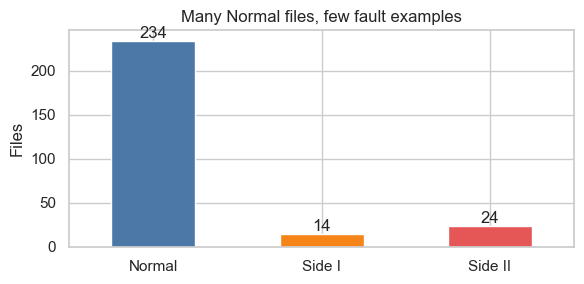

In [2]:
# I stop if the files and labels do not agree, before building any training rows.
if not TRAIN_DIR.is_dir() or not (DATASET_DIR / "Train_Labels.csv").is_file():
    raise FileNotFoundError("Training needs Dataset/Train and Dataset/Train_Labels.csv.")
labels = pd.read_csv(DATASET_DIR / "Train_Labels.csv")
if not {"filename", "label"}.issubset(labels.columns):
    raise ValueError("Train_Labels.csv needs filename and label columns.")
labels = labels[["filename", "label"]].copy()
if labels.isna().any().any() or labels["filename"].duplicated().any():
    raise ValueError("Missing labels or duplicate filenames.")
if set(labels["label"]) != set(CLASSES):
    raise ValueError("Expected exactly Normal, Side I, and Side II.")
if set(labels["filename"]) != {p.name for p in TRAIN_DIR.glob("*.csv")}:
    raise ValueError("Training filenames and labels do not match.")

counts = labels["label"].value_counts().reindex(CLASSES)
display(counts.rename("Files").to_frame())
ax = counts.plot.bar(color=["#4C78A8", "#F58518", "#E45756"], figsize=(6, 3))
ax.bar_label(ax.containers[0])
ax.set(xlabel="", ylabel="Files", title="Many Normal files, few fault examples")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 3. Feature engineering

I converted each recording into **69 candidate features** rather than treating its 10,000 rows as separate training examples:

- **Speed:** estimated speed from pulse transitions and an indicator of whether transitions occurred.
- **Time-domain summaries:** vibration and shock magnitude, peaks, and spikiness for each side.
- **Frequency-domain summaries:** Welch power-spectrum features, including dominant frequency, spectral centroid, entropy, and power in selected frequency bands.
- **Side comparisons:** log ratios comparing Side I with Side II.

### The 15 features used by my final model

I retained six vibration measurements for each rail side:

| Measurement | What it describes |
|---|---|
| Median RMS | Typical vibration magnitude across sensors |
| 90th-percentile RMS | Upper-end vibration magnitude across sensors |
| Maximum RMS | The strongest sensor's RMS magnitude |
| Maximum absolute peak | The largest absolute vibration measurement |
| Median kurtosis | Typical signal spikiness across sensors |
| 90th-percentile crest factor | Upper-end peak-to-RMS ratio across sensors |

These give **12 features** across the two sides. I added **three log ratios** comparing their 90th-percentile RMS, maximum RMS, and maximum absolute peak.

A log ratio of zero means equal measurements; positive means a larger Side I measurement, and negative means a larger Side II measurement.

My final model therefore uses **15 vibration-time features**, with **no explicit speed, shock, or frequency-domain inputs**. Filenames and labels are also excluded from its inputs.


In [3]:
# I use the Info Kit's exact header order and side assignments.
EXPECTED_HEADER = ["Rotating speed"] + [
    f"{kind} of bearing in position {position} of car {car}"
    for car in range(1, 9) for position in range(1, 9)
    for kind in ["Vibration", "Shock"]
]
# I collect each signal type into separate Side I / Side II groups (32 sensors each).
GROUP_COLUMNS = {
    (kind.lower(), side): [
        f"{kind} of bearing in position {position} of car {car}"
        for car in range(1, 9) for position in positions
    ]
    for kind in ["Vibration", "Shock"]
    for side, positions in [("side_i", [1, 3, 5, 7]), ("side_ii", [2, 4, 6, 8])]
}

def read_recording(path):
    """I load one CSV and reject recordings that do not match the sensor schema."""
    # float32 keeps memory use down and matches the precision used in my experiments.
    frame = pd.read_csv(path, dtype=np.float32)
    if frame.shape != (10_000, 129) or frame.columns.tolist() != EXPECTED_HEADER:
        raise ValueError(f"{Path(path).name}: expected 10,000 rows and the 129 ordered sensor columns.")
    # I reject missing/infinite raw measurements rather than silently filling them.
    if not np.isfinite(frame.to_numpy()).all():
        raise ValueError(f"{Path(path).name}: missing or non-finite measurements.")
    return frame

def finite_number(value):
    """I replace an undefined calculated summary with the recipe's fallback value."""
    # A constant signal can have undefined kurtosis even when all raw values are valid.
    # I keep the existing zero fallback for summaries; this does not repair missing input data.
    return float(value) if np.isfinite(value) else 0.0

def group_summary(values):
    """I summarise one signal type on one side into a dictionary of measurements.

    Rows are time samples; columns are the sensors in this group.
    I first calculate per-sensor measurements, then summarise across sensors.
    """
    # axis=0 works down time: I get one RMS magnitude and peak per sensor.
    # The RMS mean accumulates in float64, while the original samples stay float32.
    rms = np.sqrt(np.mean(np.square(values), axis=0, dtype=np.float64))
    peak = np.max(np.abs(values), axis=0)
    # Kurtosis describes extreme values; crest factor compares a peak with typical magnitude.
    kurtosis = stats.kurtosis(values, axis=0, fisher=True, bias=False)
    crest = peak / (rms + EPSILON)
    # I retain typical, high-end (90th percentile), and maximum values across sensors.
    result = {
        "rms_median": finite_number(np.median(rms)),
        "rms_p90": finite_number(np.quantile(rms, 0.90)),
        "rms_max": finite_number(np.max(rms)),
        "abs_peak_max": finite_number(np.max(peak)),
        "kurtosis_median": finite_number(np.median(kurtosis)),
        "crest_factor_p90": finite_number(np.quantile(crest, 0.90)),
    }

    # Welch averages spectra from short, overlapping windows to estimate power by frequency.
    # I average the sensors' power spectra to describe this side as a whole.
    frequencies, psd = signal.welch(
        values, fs=FS, nperseg=2048, axis=0, detrend="constant", scaling="density"
    )
    mean_psd = psd.mean(axis=1)
    # I exclude zero frequency (the constant component) from these spectral summaries.
    positive = frequencies > 0
    power = mean_psd[positive]
    frequency = frequencies[positive]
    # The area under the power-density curve estimates power over the included frequencies.
    total_power = np.trapezoid(power, frequency)
    mass = power.sum()
    # These weights describe where signal power sits, not confidence in a predicted class.
    probabilities = power / (mass + EPSILON)
    # Dominant frequency = strongest peak; centroid = power-weighted average frequency.
    # Entropy describes whether power is concentrated in a few frequencies or spread out.
    result.update({
        "dominant_frequency_hz": finite_number(frequency[np.argmax(power)]),
        "spectral_centroid_hz": finite_number((frequency * power).sum() / mass if mass > 0 else 0.0),
        "spectral_entropy": finite_number(
            -np.sum(probabilities * np.log(probabilities + EPSILON)) / np.log(len(probabilities))
        ),
    })
    # I measure power in the same frequency bands used in the earlier experiments.
    # At least two frequency points are needed to calculate a trapezoid's area.
    # The integration boundaries mean these relative powers need not sum to exactly one.
    for low, high in BANDS:
        mask = (frequencies >= low) & (frequencies < high)
        band_power = np.trapezoid(mean_psd[mask], frequencies[mask]) if mask.sum() >= 2 else 0.0
        result[f"relative_power_{low}_{high}_hz"] = finite_number(band_power / (total_power + EPSILON))
        if (low, high) == (50, 100):
            result["absolute_power_50_100_hz"] = finite_number(band_power)
    return result

def extract_features(path):
    """I turn one validated recording into its filename and 69 numeric features.

    I keep the filename for matching results, not as an input to the classifier.
    The same function is used for training recordings and new recordings.
    """
    frame = read_recording(path)
    pulses = frame.iloc[:, 0].to_numpy(dtype=np.float64)
    # I turn the pulse signal into high/low states, then count every change of state.
    high = pulses > (pulses.min() + pulses.max()) / 2
    transitions = np.count_nonzero(np.diff(high.astype(np.int8)))
    # Each of the 90 teeth produces two transitions, so 180 transitions = one revolution.
    # I divide by recording duration, then use wheel circumference and convert m/s to km/h.
    revolutions_per_second = transitions / (2 * 90 * (len(pulses) / FS))
    features = {
        "file_id": Path(path).name,
        "speed__kmh": float(revolutions_per_second * (np.pi * 0.85) * 3.6),
        "speed__is_moving": float(transitions > 0),
    }
    # Prefixes preserve which side and signal type each summary belongs to.
    for (kind, side), columns in GROUP_COLUMNS.items():
        values = frame[columns].to_numpy(dtype=np.float32, copy=False)
        features.update({f"{kind}__{side}__{name}": value
                         for name, value in group_summary(values).items()})

    comparisons = {
        "vibration": ["rms_p90", "rms_max", "abs_peak_max",
                      "relative_power_50_100_hz", "absolute_power_50_100_hz"],
        "shock": ["rms_max", "abs_peak_max"],
    }
    # log(Side I / Side II) is zero for equal values, positive for stronger Side I,
    # and negative for stronger Side II. EPSILON also handles a zero measurement.
    for kind, metrics in comparisons.items():
        for metric in metrics:
            left = features[f"{kind}__side_i__{metric}"]
            right = features[f"{kind}__side_ii__{metric}"]
            features[f"{kind}__side_log_ratio__{metric}"] = finite_number(
                np.log((left + EPSILON) / (right + EPSILON))
            )
    # The first dictionary value is the filename; I check only the numeric values after it.
    if not np.isfinite(list(features.values())[1:]).all():
        raise ValueError(f"{Path(path).name}: invalid computed features.")
    return features

# I fix the selected model's 15 feature names and order for prediction-only sessions.
VIBRATION_TIME_COLUMNS = [
    f"vibration__{side}__{metric}"
    for side in ["side_i", "side_ii"]
    for metric in ["rms_median", "rms_p90", "rms_max",
                   "abs_peak_max", "kurtosis_median", "crest_factor_p90"]
] + [f"vibration__side_log_ratio__{metric}"
     for metric in ["rms_p90", "rms_max", "abs_peak_max"]]

# I record the recipe so the loader can reject a model expecting different preprocessing.
# If I change the calculations, I must update recipe_version and retrain.
FEATURE_CONTRACT = {
    "recipe_version": "rail_features_v1",
    "samples_per_file": 10_000, "sampling_rate_hz": FS,
    "ordered_columns": EXPECTED_HEADER, "input_dtype": "float32",
    "side_i_positions": [1, 3, 5, 7], "side_ii_positions": [2, 4, 6, 8],
    "epsilon": EPSILON, "undefined_summary_value": 0.0,
    "welch_nperseg": 2048, "frequency_bands_hz": BANDS,
    "wheel_diameter_m": 0.85, "speed_sensor_teeth": 90,
    "scaling": "none",
}


In [4]:
# I process one recording at a time and keep its small summary, not the full raw dataset.
rows = []
for index, filename in enumerate(labels["filename"], start=1):
    rows.append(extract_features(TRAIN_DIR / filename))
    if index == 1 or index % 50 == 0 or index == len(labels):
        print(f"Processed {index}/{len(labels)}", flush=True)

feature_table = pd.DataFrame(rows)
feature_columns = [c for c in feature_table if c != "file_id"]
# I match labels by filename, enforce one-to-one matches, and preserve the split-defining row order.
data = labels.merge(feature_table, left_on="filename", right_on="file_id",
                    validate="one_to_one", sort=False)
assert data["filename"].tolist() == labels["filename"].tolist()
assert len(feature_columns) == 69
assert np.isfinite(data[feature_columns].to_numpy()).all()
display(pd.Series({
    "Files checked": len(data),
    "Samples per file": 10_000,
    "Columns per file": 129,
    "Files failing shape, header, or finite-value checks": 0,
    "Measurements per file": len(feature_columns),
}, name="Result").to_frame())
print("All labelled files passed the checks. No test inputs were used.")


Processed 1/272
Processed 50/272
Processed 100/272
Processed 150/272
Processed 200/272
Processed 250/272
Processed 272/272


,Result
Files checked,272
Samples per file,10000
Columns per file,129
"Files failing shape, header, or finite-value checks",0
Measurements per file,69


All labelled files passed the checks. No test inputs were used.


## 4. EDA findings

I found a clear association between class and estimated speed:

| Class | Median estimated speed |
|---|---:|
| Normal | 29.267 km/h |
| Side I | 46.651 km/h |
| Side II | 50.390 km/h |

This creates a risk that the model learns speed-related vibration rather than a fault-specific pattern.

The median side-to-side maximum-RMS log ratio was close to zero for Normal recordings, positive for Side I, and negative for Side II. This supports comparing the sides, although the distributions overlap.

Within the 40–50 km/h subset, I still observed differences between the classes in vibration magnitude and side-specific power. This is useful supporting evidence, but not proof that speed effects have been removed. A zero speed estimate from a constant pulse signal also does not independently prove the train was stationary.


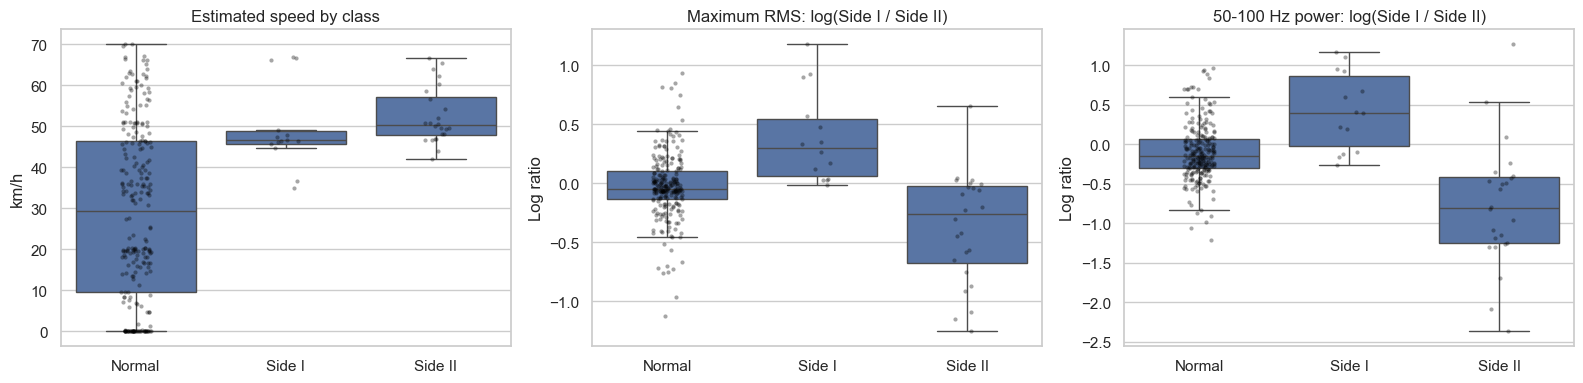

All files: class medians


,speed__kmh,vibration__side_log_ratio__rms_max,vibration__side_log_ratio__absolute_power_50_100_hz
label,,,
Normal,29.267,-0.045,-0.151
Side I,46.651,0.299,0.401
Side II,50.390,-0.263,-0.804


40-50 km/h: compare classes at similar estimated speeds


,files,side_i_max_rms,side_ii_max_rms,band_log_ratio
label,,,,
Normal,30,0.918,1.005,-0.182
Side I,9,1.603,1.261,0.602
Side II,11,1.556,1.767,-0.489


In [5]:
# I show every file as a dot so the boxplots do not hide overlap or unusual recordings.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
views = [
    ("speed__kmh", "Estimated speed by class", "km/h"),
    ("vibration__side_log_ratio__rms_max", "Maximum RMS: log(Side I / Side II)", "Log ratio"),
    ("vibration__side_log_ratio__absolute_power_50_100_hz",
     "50-100 Hz power: log(Side I / Side II)", "Log ratio"),
]
for ax, (column, title, unit) in zip(axes, views):
    sns.boxplot(data=data, x="label", y=column, order=CLASSES, showfliers=False, ax=ax)
    sns.stripplot(data=data, x="label", y=column, order=CLASSES,
                  color="black", alpha=0.35, size=3, ax=ax)
    ax.set(title=title, xlabel="", ylabel=unit)
plt.tight_layout()
plt.show()

evidence = [v[0] for v in views]
print("All files: class medians")
display(data.groupby("label")[evidence].median().reindex(CLASSES).round(3))
overlap = data[data["speed__kmh"].between(40, 50)]
print("40-50 km/h: compare classes at similar estimated speeds")
display(overlap.groupby("label").agg(
    files=("file_id", "size"),
    side_i_max_rms=("vibration__side_i__rms_max", "median"),
    side_ii_max_rms=("vibration__side_ii__rms_max", "median"),
    band_log_ratio=("vibration__side_log_ratio__absolute_power_50_100_hz", "median"),
).reindex(CLASSES).round(3))


### Signal observations

The example plots show how vibration magnitude changes within a recording and how its power is distributed across frequencies. I selected the first listed recording from each class rather than choosing examples by appearance.

These plots illustrate the signals; the comparisons across all recordings provide the broader evidence. Neither a single large peak nor one example spectrum establishes corrugation by itself.


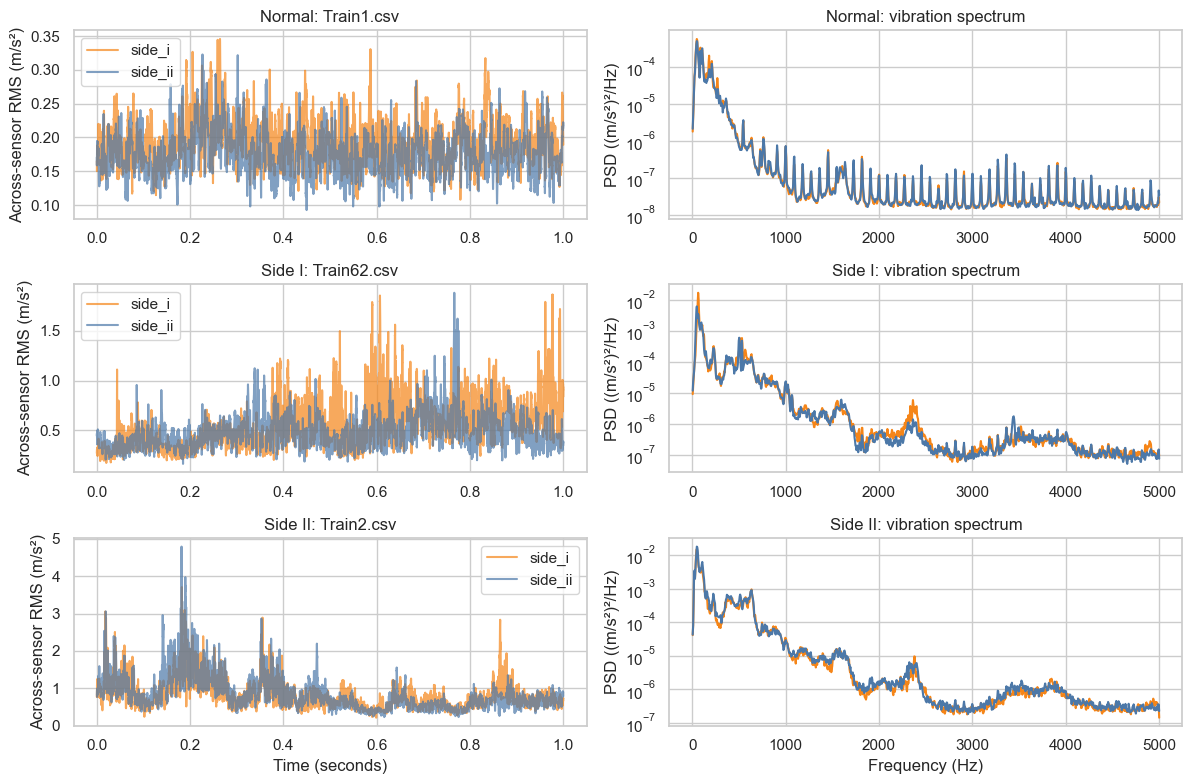

In [6]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
time = np.arange(10_000) / FS
for row, label in enumerate(CLASSES):
    filename = labels.loc[labels["label"] == label, "filename"].iloc[0]
    frame = read_recording(TRAIN_DIR / filename)
    for side, color in [("side_i", "#F58518"), ("side_ii", "#4C78A8")]:
        values = frame[GROUP_COLUMNS[("vibration", side)]].to_numpy(dtype=np.float32)
        # I combine this side's sensors into one RMS trace at each instant (axis=1).
        trace = np.sqrt(np.mean(np.square(values), axis=1, dtype=np.float64))
        frequency, psd = signal.welch(values, fs=FS, nperseg=2048, axis=0,
                                      detrend="constant", scaling="density")
        axes[row, 0].plot(time, trace, color=color, alpha=0.7, label=side)
        axes[row, 1].semilogy(frequency[1:], psd.mean(axis=1)[1:], color=color, label=side)
    axes[row, 0].set(title=f"{label}: {filename}", ylabel="Across-sensor RMS (m/s²)")
    axes[row, 1].set(title=f"{label}: vibration spectrum", ylabel="PSD ((m/s²)²/Hz)")
    axes[row, 0].legend()
axes[-1, 0].set_xlabel("Time (seconds)")
axes[-1, 1].set_xlabel("Frequency (Hz)")
plt.tight_layout()
plt.show()


## 5. Evaluation method and metric

I used **stratified five-fold cross-validation repeated five times**, giving 25 validation scores. Each split trained on roughly 80% of the labelled files and evaluated on the remaining 20%, while keeping class proportions similar. Every model received the same splits.

My primary metric is **Macro F1**, the equal-weight average of the three class-specific F1 scores. A score of 0.813 does **not** mean 81.3% accuracy. I report the mean and standard deviation across folds; the standard deviation is not a confidence interval.

I also used a **separate fixed five-fold split** to obtain one out-of-fold prediction per recording. Each prediction came from a model that did not train on that recording. I used these predictions for per-class scores, the confusion matrix, and speed-subset checks.

For Logistic Regression, scaling was fitted within each training fold. Logistic Regression and Extra Trees used balanced class weights; I did not oversample, undersample, or create synthetic recordings.


In [7]:
y = data["label"]
vibration = [c for c in feature_columns if c.startswith("vibration__")]
# I exclude frequency/power features here to isolate the compact time-domain recipe.
vibration_time = [c for c in vibration if not any(w in c for w in ("frequency", "spectral", "power"))]
all_signals = [c for c in feature_columns if not c.startswith("speed__")]
assert len(vibration_time) == 15

# I build the splits once so a model cannot benefit from receiving an easier split.
# Stratification keeps class proportions similar; repeats reshuffle the file assignments.
repeated_splits = list(RepeatedStratifiedKFold(
    n_splits=5, n_repeats=5, random_state=SEED
).split(data, y))
fixed_splits = list(StratifiedKFold(
    n_splits=5, shuffle=True, random_state=SEED
).split(data, y))

def logistic():
    """I create a fresh scaling-plus-Logistic-Regression pipeline."""
    # Keeping scaling inside the pipeline means each fold learns it from training data only.
    # Balanced weights give each rare fault example more influence than a Normal example.
    return make_pipeline(StandardScaler(), LogisticRegression(
        class_weight="balanced", max_iter=5000, random_state=SEED
    ))

def trees(max_features="sqrt"):
    """I create an unfitted Extra Trees model with the chosen feature-sampling rule."""
    # max_features controls how many features each split may consider.
    # min_samples_leaf=2 avoids leaves supported by just one training recording.
    return ExtraTreesClassifier(
        n_estimators=250, min_samples_leaf=2, max_features=max_features,
        class_weight="balanced", random_state=SEED, n_jobs=-1
    )

def score_subset(predictions, mask):
    """I score only the recordings selected by a Boolean mask."""
    # I keep all three classes in the metric; an empty subset has no score (NaN).
    return f1_score(y[mask], predictions[mask], labels=CLASSES,
                    average="macro", zero_division=0) if mask.any() else np.nan

def evaluate(name, estimator, columns):
    """I return a score summary and one fixed-fold prediction per recording.

    The estimator is a recipe: cross-validation fits separate copies per fold.
    This function does not return a final model trained on all recordings.
    """
    X = data[columns]
    # These 25 fold scores describe variation across the repeated validation splits.
    scores = cross_val_score(estimator, X, y, cv=repeated_splits,
                             scoring="f1_macro", error_score="raise")
    # I use a separate, non-repeated five-fold split to get exactly one OOF prediction per file.
    predicted = cross_val_predict(estimator, X, y, cv=fixed_splits, method="predict")
    # Per-class scores expose weak fault detection that an overall score could hide.
    per_class = f1_score(y, predicted, labels=CLASSES, average=None, zero_division=0)
    # The mean fold F1 and the F1 of all pooled OOF predictions are different summaries.
    # Speed masks reuse OOF predictions; they do not retrain or use the official Test files.
    row = {
        "experiment": name, "features": len(columns),
        "mean_macro_f1": scores.mean(), "std_macro_f1": scores.std(),
        "oof_macro_f1": f1_score(y, predicted, labels=CLASSES, average="macro", zero_division=0),
        "normal_f1": per_class[0], "side_i_f1": per_class[1], "side_ii_f1": per_class[2],
        "high_speed_f1": score_subset(predicted, data["speed__kmh"].ge(40).to_numpy()),
        "overlap_40_50_f1": score_subset(predicted, data["speed__kmh"].between(40, 50).to_numpy()),
    }
    return row, predicted


## 6. Baseline and final-model comparison

My baseline and refinement comparisons produced the following results under the same repeated-validation strategy:

| Model | Features | Mean Macro F1 ± fold standard deviation |
|---|---|---:|
| Always predict Normal | No meaningful signal information | 0.308 ± 0.002 |
| Logistic Regression | Estimated speed only | 0.441 ± 0.058 |
| Logistic Regression | 15 vibration-time features | 0.715 ± 0.094 |
| Original Extra Trees | 15 vibration-time features | 0.766 ± 0.090 |
| Logistic Regression | 67 vibration and shock features | 0.759 ± 0.092 |
| **Refined Extra Trees — selected** | **15 vibration-time features** | **0.813 ± 0.122** |

The signal-based models outperformed the always-Normal and speed-only baselines. The refined Extra Trees model achieved the highest mean score among these comparisons. This does not establish that shock or frequency features are universally unhelpful—only that the broader tested combination was not the strongest here.


In [8]:
# I pass each model and its feature set through the same evaluation function.
experiments = {
    "Always Normal": (DummyClassifier(strategy="most_frequent"), ["speed__kmh"]),
    "Speed only": (logistic(), ["speed__kmh"]),
    "Vibration time - Logistic": (logistic(), vibration_time),
    "Vibration time - Extra Trees": (trees(), vibration_time),
    "Vibration + shock - Logistic": (logistic(), all_signals),
}
results = []
oof_predictions = {}
for name, (estimator, columns) in experiments.items():
    print("Evaluating:", name, flush=True)
    row, predicted = evaluate(name, estimator, columns)
    results.append(row)
    oof_predictions[name] = predicted
baseline_results = pd.DataFrame(results)
display(baseline_results.round(3))


Evaluating: Always Normal
Evaluating: Speed only
Evaluating: Vibration time - Logistic
Evaluating: Vibration time - Extra Trees
Evaluating: Vibration + shock - Logistic


,experiment,features,mean_macro_f1,std_macro_f1,oof_macro_f1,normal_f1,side_i_f1,side_ii_f1,high_speed_f1,overlap_40_50_f1
0,Always Normal,1,0.308,0.002,0.308,0.925,0.000,0.000,0.271,0.250
1,Speed only,1,0.441,0.058,0.438,0.805,0.250,0.260,0.204,0.188
2,Vibration time - Logistic,15,0.715,0.094,0.711,0.945,0.455,0.735,0.665,0.695
3,Vibration time - Extra Trees,15,0.766,0.090,0.764,0.966,0.552,0.776,0.718,0.757
4,Vibration + shock - Logistic,67,0.759,0.092,0.788,0.961,0.629,0.776,0.781,0.781


## 7. Baseline error findings

The original Extra Trees baseline made **20 mistakes out of 272 fixed-fold predictions**:

- 9 Normal recordings were flagged as faults.
- 6 Side I recordings received the wrong class.
- 5 Side II recordings received the wrong class.

Several false alarms occurred at high estimated speeds. Some fault recordings also had similar vibration magnitude on the two sides, making the side distinction less obvious.

I treated these as patterns to investigate, not proof of why any individual prediction was wrong.


In [9]:
# I inspect held-out predictions, not predictions on a model's own training examples.
baseline_name = "Vibration time - Extra Trees"
error_view = data[[
    "file_id", "label", "speed__kmh", "vibration__side_log_ratio__rms_max"
]].copy()
error_view["prediction"] = oof_predictions[baseline_name]
error_view["correct"] = error_view["label"] == error_view["prediction"]
display(error_view.loc[~error_view["correct"]].sort_values(["label", "speed__kmh"]).round(3))
display(error_view.groupby(["label", "correct"]).agg(
    files=("file_id", "size"),
    median_speed=("speed__kmh", "median"),
    median_side_ratio=("vibration__side_log_ratio__rms_max", "median"),
).round(3))


,file_id,label,speed__kmh,vibration__side_log_ratio__rms_max,prediction,correct
250,Train251.csv,Normal,50.149,-0.112,Side I,False
168,Train169.csv,Normal,58.321,-0.419,Side II,False
122,Train123.csv,Normal,66.278,0.058,Side I,False
133,Train134.csv,Normal,66.438,-0.329,Side II,False
254,Train255.csv,Normal,66.972,0.051,Side I,False
129,Train130.csv,Normal,67.026,-0.090,Side I,False
88,Train89.csv,Normal,69.589,0.025,Side II,False
262,Train263.csv,Normal,69.963,0.091,Side II,False
46,Train47.csv,Normal,70.123,0.001,Side II,False
136,Train137.csv,Side I,44.809,0.571,Normal,False


files  median_speed  median_side_ratio
label   correct                                        
Normal  False        9        66.972              0.001
        True       225        23.392             -0.046
Side I  False        6        56.772              0.108
        True         8        46.357              0.343
Side II False        5        46.998             -0.004
        True        19        50.844             -0.299

## 8. Effect of the refinement

I changed Extra Trees' `max_features` from `"sqrt"` to `0.75`, allowing each tree split to consider more of the available features. The 15 features, data, and validation splits stayed the same.

The mean repeated-validation Macro F1 increased from **0.766 to 0.813**. In the separate fixed-fold evaluation, Side I F1 increased from **0.552 to 0.714**, and total mistakes fell from **20 to 12**.

This improvement came from changing the model's settings, not adding recordings or new features.


,experiment,features,mean_macro_f1,std_macro_f1,oof_macro_f1,normal_f1,side_i_f1,side_ii_f1,high_speed_f1,overlap_40_50_f1
5,Vibration time - Refined Extra Trees,15,0.813,0.122,0.851,0.981,0.714,0.857,0.830,0.875
3,Vibration time - Extra Trees,15,0.766,0.090,0.764,0.966,0.552,0.776,0.718,0.757
4,Vibration + shock - Logistic,67,0.759,0.092,0.788,0.961,0.629,0.776,0.781,0.781
2,Vibration time - Logistic,15,0.715,0.094,0.711,0.945,0.455,0.735,0.665,0.695
1,Speed only,1,0.441,0.058,0.438,0.805,0.250,0.260,0.204,0.188
0,Always Normal,1,0.308,0.002,0.308,0.925,0.000,0.000,0.271,0.250


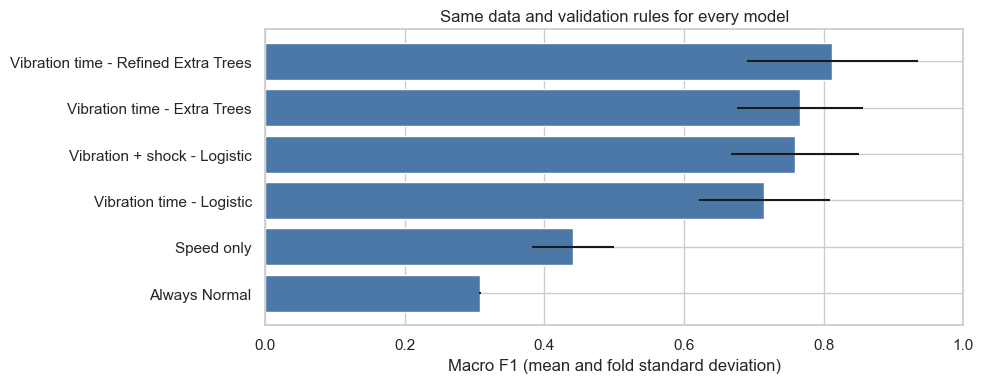

In [10]:
# I change only max_features; the data, feature list, and validation rules stay fixed.
refined_name = "Vibration time - Refined Extra Trees"
experiments[refined_name] = (trees(max_features=0.75), vibration_time)
row, predicted = evaluate(refined_name, *experiments[refined_name])
results.append(row)
oof_predictions[refined_name] = predicted
comparison = pd.DataFrame(results).sort_values("mean_macro_f1", ascending=False)
display(comparison.round(3))

plot_data = comparison.sort_values("mean_macro_f1")
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(plot_data["experiment"], plot_data["mean_macro_f1"],
        xerr=plot_data["std_macro_f1"], color="#4C78A8")
ax.set(xlim=(0, 1), xlabel="Macro F1 (mean and fold standard deviation)",
       title="Same data and validation rules for every model")
plt.tight_layout()
plt.show()


## 9. Final model and validation results

I selected **Extra Trees Classifier** with:

- **250 trees**.
- **15 vibration-time features**.
- **Balanced class weights**.
- **`max_features=0.75`**.
- **`min_samples_leaf=2`**.
- **Random seed 42**.

My headline result is **Macro F1 = 0.813 ± 0.122** from repeated five-fold validation.

The separate fixed-five-fold evaluation produced **Macro F1 = 0.851**, with:

| Class | Fixed-fold F1 |
|---|---:|
| Normal | 0.981 |
| Side I | 0.714 |
| Side II | 0.857 |

There were **12 mistakes out of 272 fixed-fold predictions**. Side I remained the weakest class.

On subsets of those same fixed-fold predictions, Macro F1 was **0.830 at speeds of at least 40 km/h** and **0.875 within 40–50 km/h**. These are subset diagnostics, not independent test results. The 0.813 and 0.851 scores summarise different validation calculations and are not interchangeable.


Selected candidate: Vibration time - Refined Extra Trees
Measurements used: 15


features            15.000
mean_macro_f1        0.813
std_macro_f1         0.122
oof_macro_f1         0.851
normal_f1            0.981
side_i_f1            0.714
side_ii_f1           0.857
high_speed_f1        0.830
overlap_40_50_f1     0.875
Name: Vibration time - Refined Extra Trees, dtype: float64

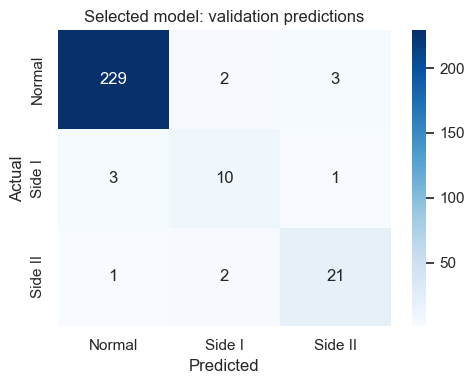

Fixed-fold mistakes: 12 / 272


,file_id,label,speed__kmh,prediction
196,Train197.csv,Normal,39.308,Side II
250,Train251.csv,Normal,50.149,Side II
176,Train177.csv,Normal,56.398,Side I
168,Train169.csv,Normal,58.321,Side II
122,Train123.csv,Normal,66.278,Side I
99,Train100.csv,Side I,46.518,Side II
184,Train185.csv,Side I,66.225,Normal
179,Train180.csv,Side I,66.759,Normal
201,Train202.csv,Side I,66.972,Normal
187,Train188.csv,Side II,43.954,Normal


In [11]:
selected_name = refined_name
selected_columns = list(vibration_time)
selected_estimator = trees(max_features=0.75)  # I keep an unfitted recipe for the final training step.
selected_result = comparison.set_index("experiment").loc[selected_name]
print("Selected candidate:", selected_name)
print("Measurements used:", len(selected_columns))
display(selected_result.round(3))
if comparison.iloc[0]["experiment"] != selected_name:
    print("Review needed: another experiment led the current run.")

predicted = oof_predictions[selected_name]
# Rows are actual classes and columns are predicted classes; off-diagonal counts are mistakes.
matrix = confusion_matrix(y, predicted, labels=CLASSES)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax)
ax.set(xlabel="Predicted", ylabel="Actual", title="Selected model: validation predictions")
plt.tight_layout()
plt.show()

mistakes = data[["file_id", "label", "speed__kmh"]].copy()
mistakes["prediction"] = predicted
mistakes = mistakes[mistakes["label"] != mistakes["prediction"]]
print(f"Fixed-fold mistakes: {len(mistakes)} / {len(data)}")
display(mistakes.sort_values(["label", "speed__kmh"]).round(3))


## 10. Final training outcome

I fitted the selected model on **all 272 labelled training recordings**, using the same 15 features and selected settings. No official Test recordings were used for this fit.

The saved result, `rail_corrugation.joblib`, contains the fitted model together with its feature order, preprocessing description, training information, validation metrics, and package versions.

Saving and reloading preserved the model's predictions on all training feature rows. This confirms consistency of the saved model, not its performance on unseen data. The reported performance remains the development-validation results above.


In [12]:
# I check that this run still supports the selected model and its expected feature order.
if selected_columns != VIBRATION_TIME_COLUMNS:
    raise ValueError("Review the selected feature recipe before final training.")
if comparison.iloc[0]["experiment"] != selected_name:
    raise ValueError("Another model leads this run; review section 9 before saving.")
X_final = data.loc[:, selected_columns]
y_final = data["label"]
assert len(data) == len(labels) == 272
assert data["file_id"].tolist() == labels["filename"].tolist()
assert np.isfinite(X_final.to_numpy()).all()

# clone keeps the chosen settings but starts with no fitted state.
# This fit uses every labelled Train recording, never the official Test recordings.
final_model = clone(selected_estimator).fit(X_final, y_final)
# I save the model together with the information needed to reproduce its inputs.
model_bundle = {
    "format_version": 1,
    "model": final_model,
    "feature_columns": list(selected_columns),
    "classes": list(CLASSES),
    "feature_contract": FEATURE_CONTRACT,
    "versions": VERSIONS,
    "training": {
        "trained_at_utc": datetime.now(timezone.utc).isoformat(),
        "files": len(data),
        "class_counts": y_final.value_counts().to_dict(),
        "filenames": data["file_id"].tolist(),
        "random_seed": SEED,
        "experiment": selected_name,
    },
    "development_validation": {
        "method": "5-fold x 5-repeat stratified CV; fixed 5-fold OOF; seed 42",
        "independent_test_score": False,
        "metrics": selected_result.to_dict(),
    },
}

MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
# I write a temporary copy first, preserving the current model until reload checks pass.
pending_path = MODEL_PATH.with_suffix(".pending.joblib")
joblib.dump(model_bundle, pending_path, compress=3)
reloaded_bundle = joblib.load(pending_path)  # I only load the trusted file I just created.
# I check that saving preserves both class predictions and the underlying class scores.
# These are consistency checks, not estimates of unseen-file performance.
np.testing.assert_array_equal(final_model.predict(X_final),
                              reloaded_bundle["model"].predict(X_final))
np.testing.assert_allclose(final_model.predict_proba(X_final),
                           reloaded_bundle["model"].predict_proba(X_final),
                           rtol=0, atol=1e-12)
assert reloaded_bundle["feature_columns"] == selected_columns
assert reloaded_bundle["feature_contract"] == FEATURE_CONTRACT
pending_path.replace(MODEL_PATH)
print(f"Trained on {len(data)} labelled files using {len(selected_columns)} features.")
print("Saved:", MODEL_PATH)


Trained on 272 labelled files using 15 features.
Saved: C:\Users\Billy\OneDrive\Documents\GitHub\nebula-hackathon\Backend\Rail_Corrugation\models\rail_corrugation.joblib


## 11. Prediction outcome

For a new recording, my prediction function validates the input, calculates the same features used in training, selects the saved 15-feature order, and returns a filename and one of the three class labels.

The saved classifier consumes these features, not the raw CSV directly. Prediction does not retrain the model or require training labels. Invalid input shape, column order, or missing/non-finite measurements are rejected.


In [13]:
def load_rail_model(model_path=MODEL_PATH):
    """I load a trusted model bundle and check that this notebook can use it."""
    model_path = Path(model_path)
    if not model_path.is_file():
        raise FileNotFoundError(f"Saved model not found: {model_path}. Run section 10 first.")
    # Loading can execute pickle code, so this path must never be an untrusted model upload.
    bundle = joblib.load(model_path)
    if not isinstance(bundle, dict) or bundle.get("format_version") != 1:
        raise ValueError("Not a supported Rail Corrugation model bundle.")
    # Correct predictions require the same calculations AND the same feature order.
    if bundle.get("feature_contract") != FEATURE_CONTRACT:
        raise ValueError("The saved model and notebook use different feature recipes.")
    columns = bundle.get("feature_columns")
    if columns != VIBRATION_TIME_COLUMNS:
        raise ValueError("The saved model has an unexpected feature order.")
    model = bundle.get("model")
    if not isinstance(model, ExtraTreesClassifier) or not hasattr(model, "feature_names_in_"):
        raise ValueError("The bundle does not contain a fitted Extra Trees model.")
    # I also check the fitted estimator itself, not just the bundle's description.
    if list(model.feature_names_in_) != columns or list(model.classes_) != CLASSES:
        raise ValueError("The fitted model's inputs or classes do not match.")
    # I reject version differences that could change feature calculations or model behaviour.
    for package in ["numpy", "pandas", "scipy", "sklearn"]:
        saved_version = bundle.get("versions", {}).get(package)
        if saved_version != VERSIONS[package]:
            raise ValueError(f"Use {package}=={saved_version}; current version is {VERSIONS[package]}.")
    return bundle

def predict_file(file_path, model_path=MODEL_PATH):
    """I predict one CSV without retraining and return its filename and class label."""
    file_path = Path(file_path)
    if not file_path.is_file():
        raise FileNotFoundError(f"Sensor file not found: {file_path}")
    if file_path.suffix.lower() != ".csv":
        raise ValueError("Choose a sensor recording in CSV format.")
    bundle = load_rail_model(model_path)
    features = extract_features(file_path)
    # Extraction returns all 69 features; I select only the saved 15 in their training order.
    # The filename and unused features never reach the classifier.
    measurements = pd.DataFrame([features]).loc[:, bundle["feature_columns"]]
    prediction = str(bundle["model"].predict(measurements)[0])
    return {"file_id": file_path.name, "prediction": prediction}


### Example prediction

The recorded example classified **`Test32.csv` as Side I**. This demonstrates a prediction from the saved model; it does not establish that the classification is correct because the organisers hold the Test labels.

I did not use this prediction to select features or tune the model.


In [14]:
# I can change this path to another recording without retraining the model.
example_path = DATASET_DIR / "Test" / "Test32.csv"
if example_path.is_file():
    display(predict_file(example_path))
else:
    print('To predict your file, call: predict_file(Path("path/to/recording.csv"))')


{'file_id': 'Test32.csv', 'prediction': 'Side I'}

## Overall conclusion and limitations

My strongest tested approach is a compact Extra Trees classifier using side-specific vibration summaries and side-to-side ratios. It achieved **0.813 mean validation Macro F1**, while retaining weaker performance on the rare Side I class.

The main limitations are:

- **Few fault examples:** only 14 Side I and 24 Side II recordings, leaving roughly 2–3 Side I examples per validation fold.
- **Speed effects:** removing the explicit speed input does not prevent the model from learning speed-related information through vibration.
- **Unknown recording groups:** no run or session IDs are available, so file-level splits cannot rule out related recordings appearing in both training and validation.
- **Development-set reuse:** EDA and model selection used these labelled recordings. Repeating splits is a stability check, not an independent final test.
